# Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
import joblib
from pathlib import Path

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


# Load Dataset

In [2]:
df = pd.read_csv('../datasets/breast_cancer.csv')
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print("Shape     :", df.shape)
print("Columns   :", list(df.columns))
df.head()

Shape     : (569, 31)
Columns   : ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Basic Info

In [3]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se         

# Null Check

In [4]:
print("=== Null Values ===")
print(df.isnull().sum())
print("\nTotal nulls:", df.isnull().sum().sum())

=== Null Values ===
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total nulls: 0


#  Target Distribution

In [5]:
print("=== Target Distribution ===")
print(df['diagnosis'].value_counts())
print(f"\nBenign    : {sum(df['diagnosis']=='B')} ({sum(df['diagnosis']=='B')/len(df)*100:.1f}%)")
print(f"Malignant : {sum(df['diagnosis']=='M')} ({sum(df['diagnosis']=='M')/len(df)*100:.1f}%)")

=== Target Distribution ===
diagnosis
B    357
M    212
Name: count, dtype: int64

Benign    : 357 (62.7%)
Malignant : 212 (37.3%)


# Target Distribution Plot

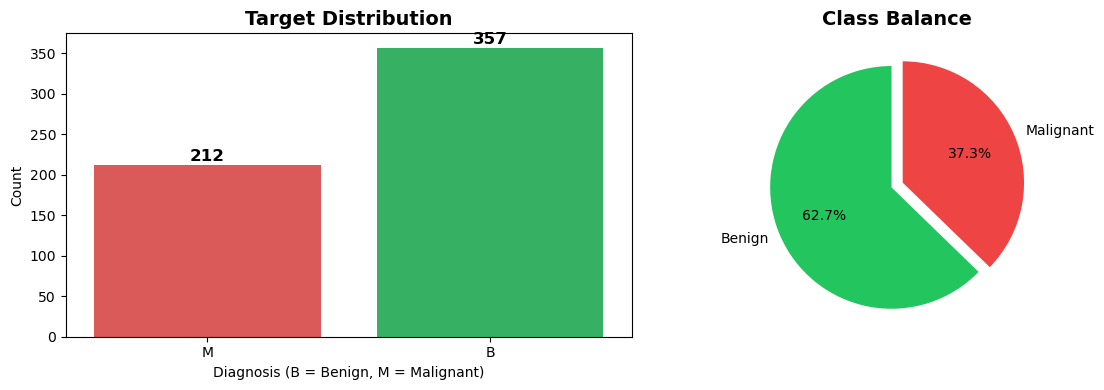

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='diagnosis', palette={'B': '#22c55e', 'M': '#ef4444'}, ax=axes[0])
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis (B = Benign, M = Malignant)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(
    df['diagnosis'].value_counts(),
    labels=['Benign', 'Malignant'],
    autopct='%1.1f%%',
    colors=['#22c55e', '#ef4444'],
    startangle=90,
    explode=(0.05, 0.05)
)
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical Summary

In [7]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


# Feature Distributions (Mean Features)

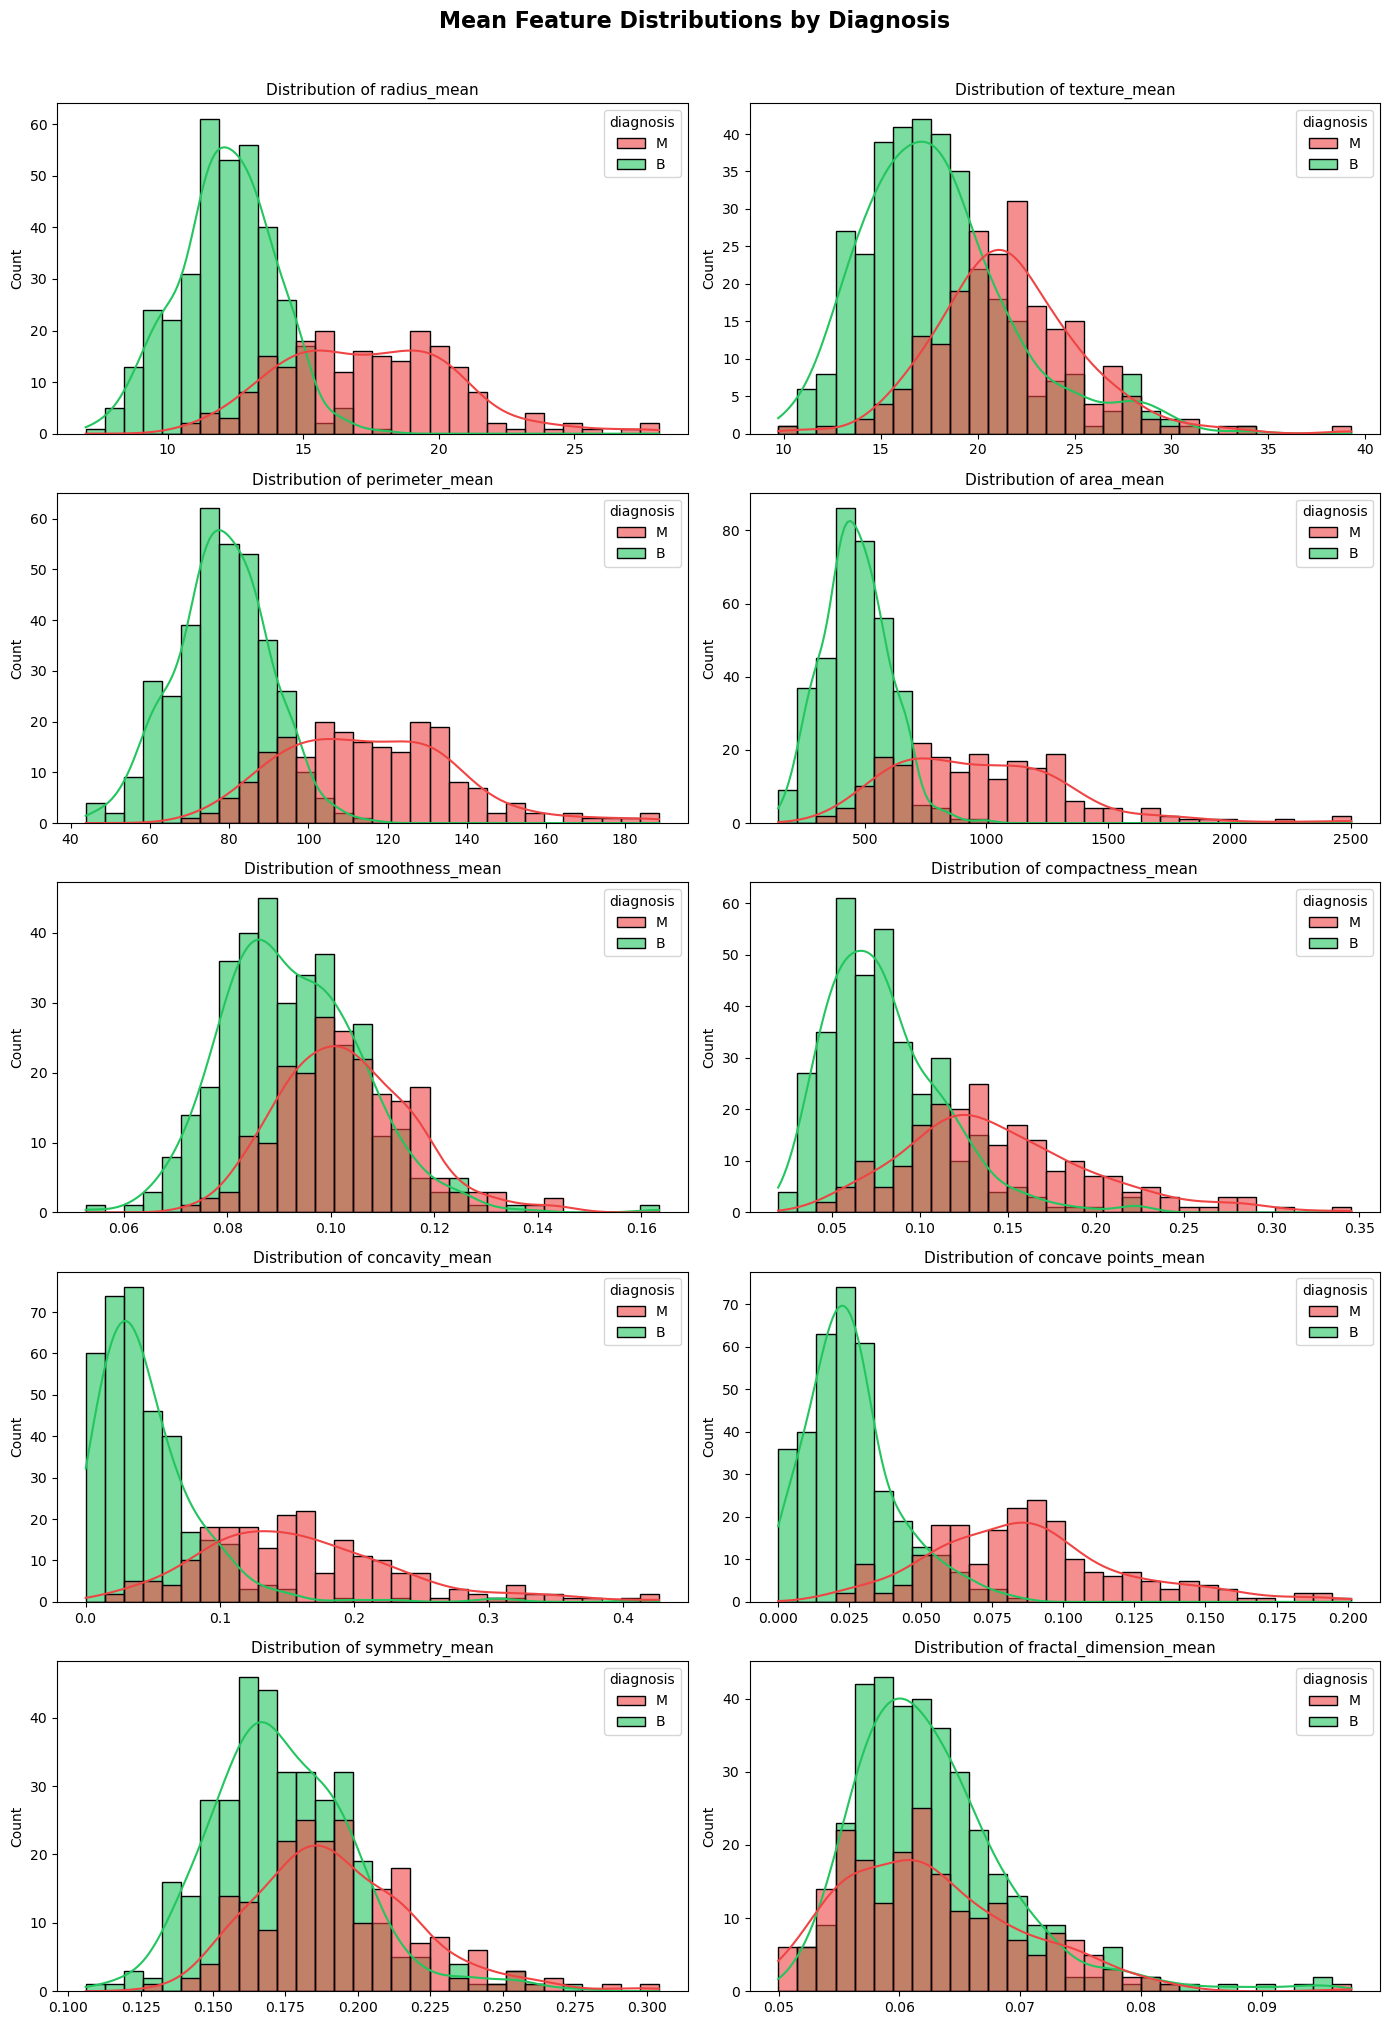

In [8]:
mean_features = [c for c in df.columns if '_mean' in c]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.histplot(data=df, x=col, hue='diagnosis',
                 palette={'B': '#22c55e', 'M': '#ef4444'},
                 kde=True, bins=30, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Mean Feature Distributions by Diagnosis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Correlation Heatmap

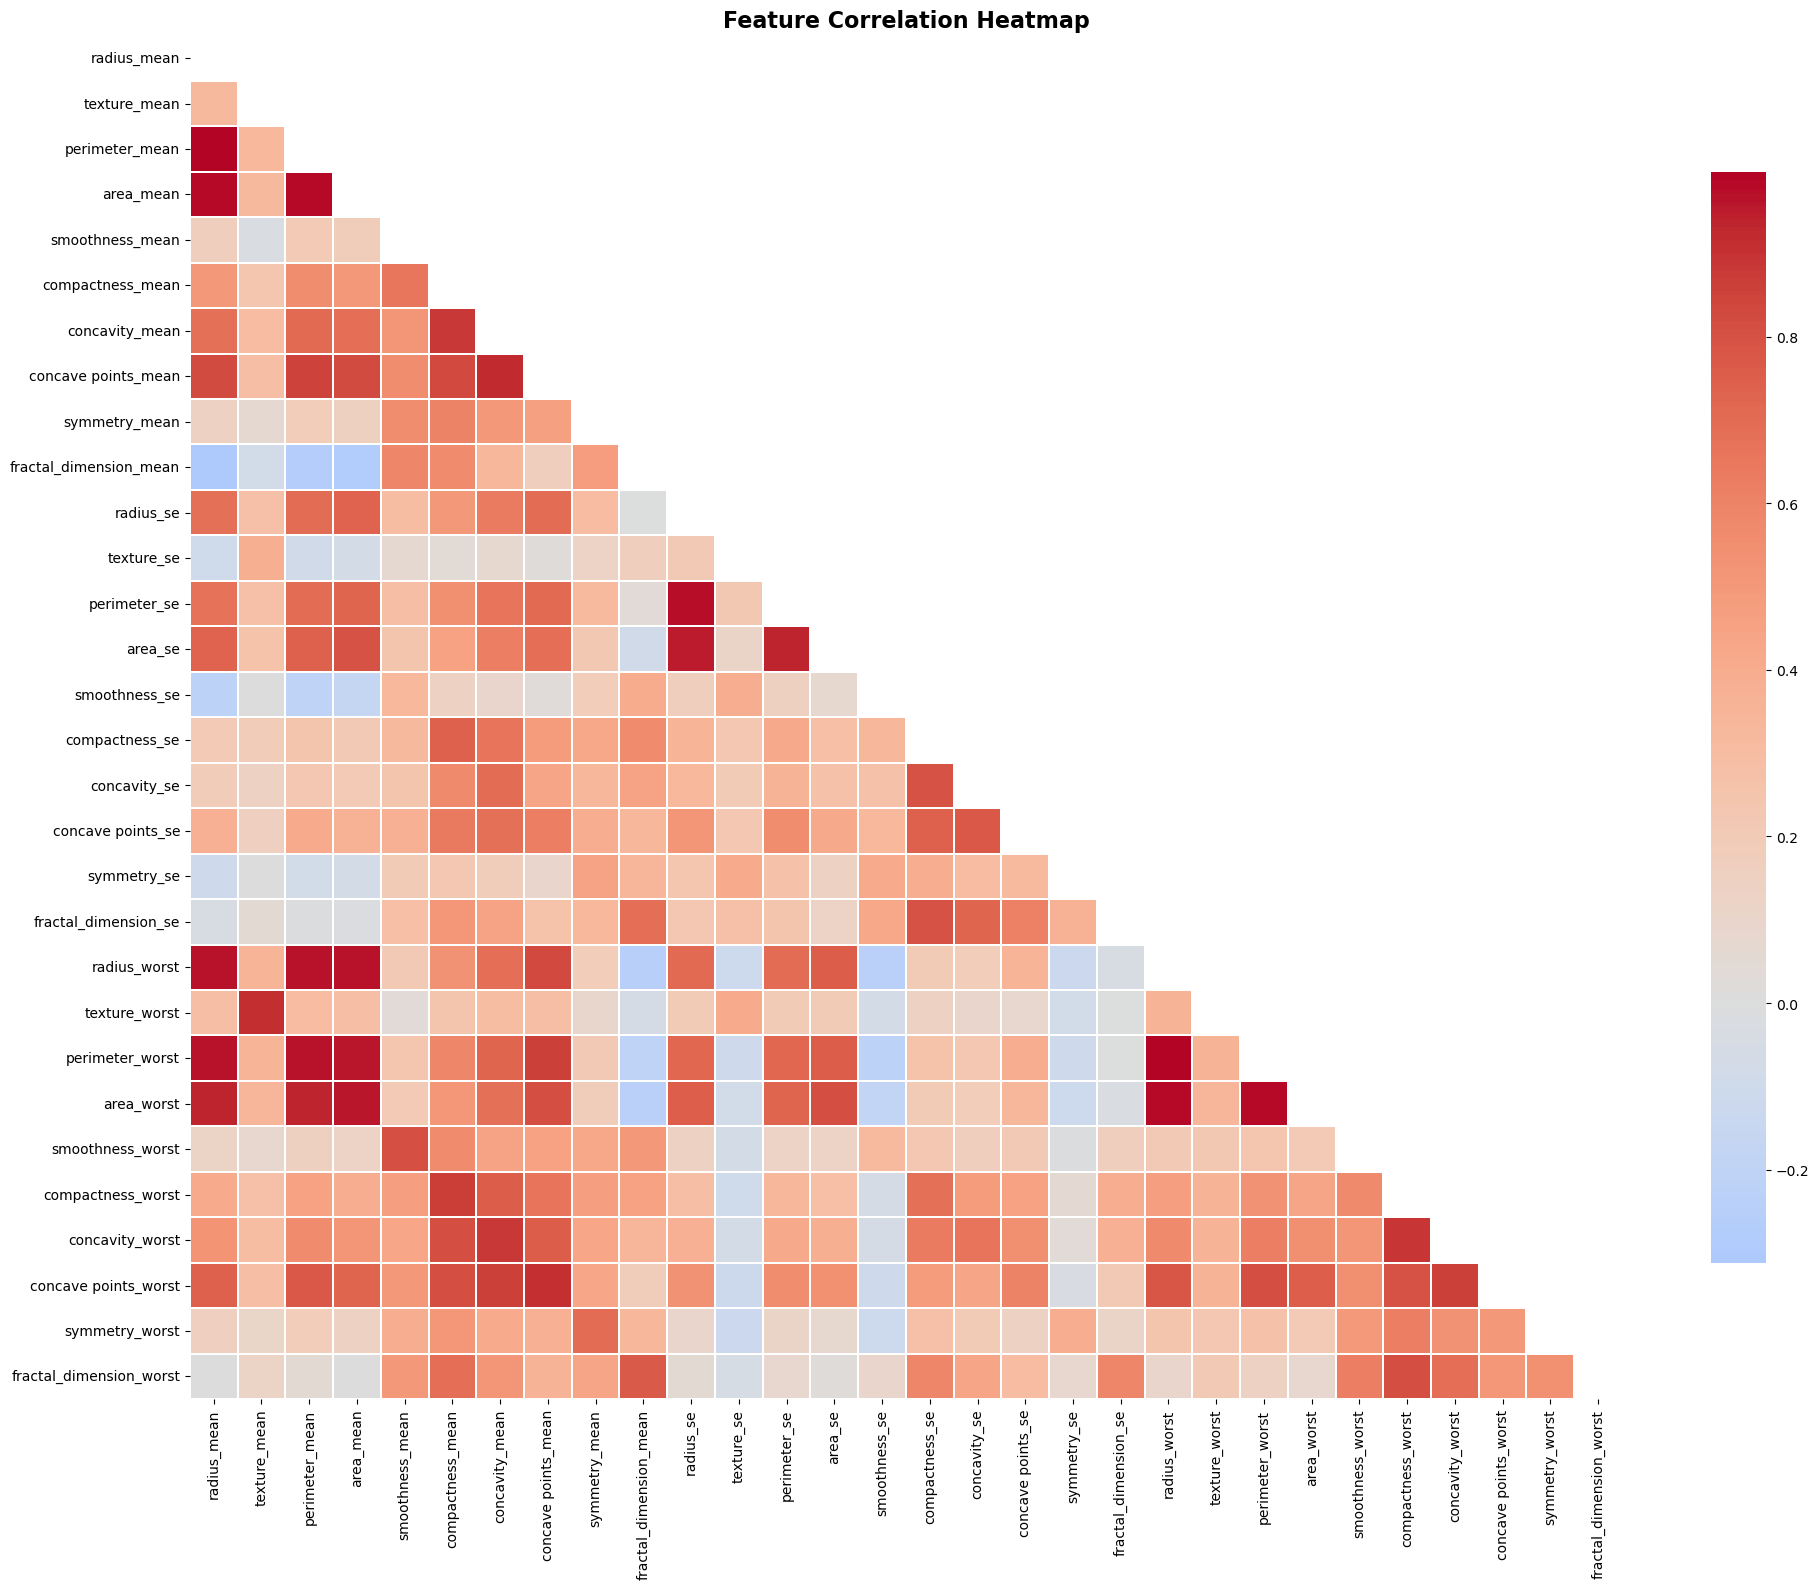

In [9]:
plt.figure(figsize=(20, 16))
corr = df.drop(columns=['diagnosis']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top Correlations with Target

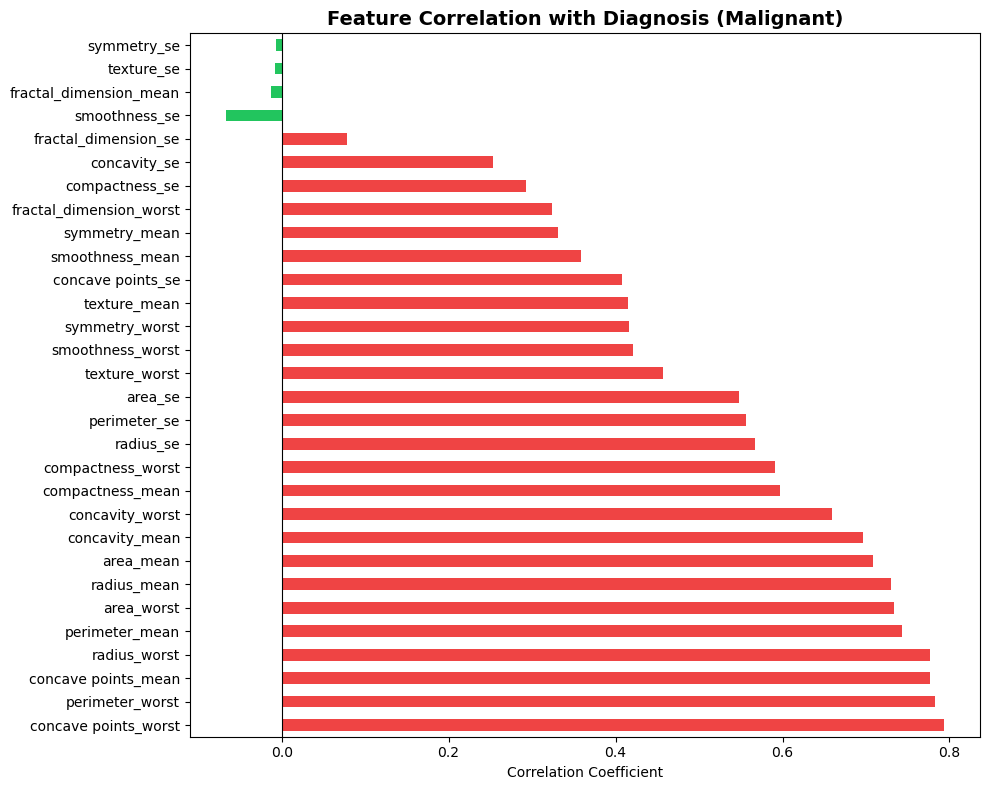

Top 5 positively correlated features:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
Name: diagnosis_num, dtype: float64


In [10]:
df_corr = df.copy()
df_corr['diagnosis_num'] = (df_corr['diagnosis'] == 'M').astype(int)

target_corr = df_corr.drop(columns=['diagnosis']).corr()['diagnosis_num'].drop('diagnosis_num')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#ef4444' if v > 0 else '#22c55e' for v in target_corr[target_corr_sorted.index]]
target_corr[target_corr_sorted.index].plot(kind='barh', color=colors, ax=plt.gca())
plt.title('Feature Correlation with Diagnosis (Malignant)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 positively correlated features:")
print(target_corr.sort_values(ascending=False).head(5))

# Boxplots (Top Features)

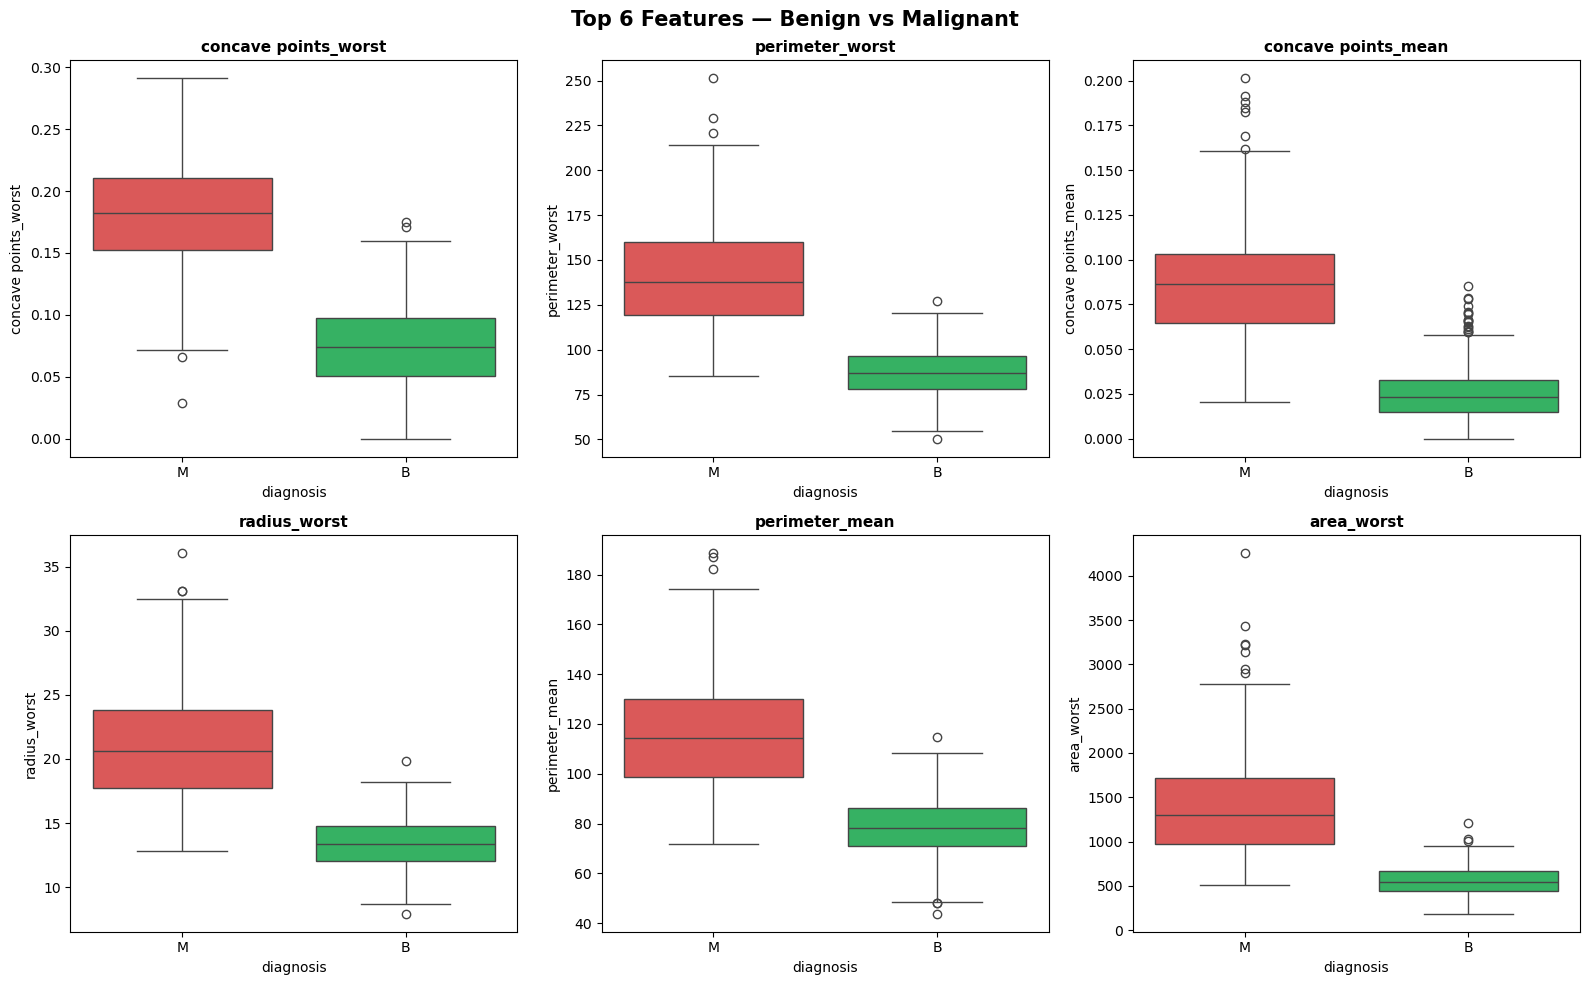

In [11]:
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(data=df, x='diagnosis', y=col,
                palette={'B': '#22c55e', 'M': '#ef4444'}, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')

plt.suptitle('Top 6 Features — Benign vs Malignant', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Encode Target & Split

In [12]:
X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)   # M = 1 (Malignant), B = 0 (Benign)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples  : {len(df)}")
print(f"Train samples  : {len(X_train)}")
print(f"Test samples   : {len(X_test)}")
print(f"\nTrain — Benign: {sum(y_train==0)}  Malignant: {sum(y_train==1)}")
print(f"Test  — Benign: {sum(y_test==0)}   Malignant: {sum(y_test==1)}")

Total samples  : 569
Train samples  : 455
Test samples   : 114

Train — Benign: 285  Malignant: 170
Test  — Benign: 72   Malignant: 42


# Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ StandardScaler applied")
print(f"   X_train_sc shape : {X_train_sc.shape}")
print(f"   X_test_sc shape  : {X_test_sc.shape}")

✅ StandardScaler applied
   X_train_sc shape : (455, 30)
   X_test_sc shape  : (114, 30)


# Model Comparison (5-Fold CV)

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM'                : SVC(probability=True, kernel='rbf', random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200, eval_metric='logloss',
                                          random_state=42, verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} {'F1 (CV)':<12} {'ROC-AUC (CV)'}")
print("-" * 50)

for name, model in models.items():
    f1  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1').mean()
    auc = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {'F1': f1, 'ROC_AUC': auc}
    print(f"{name:<25} {f1:.4f}       {auc:.4f}")

best_name = max(results, key=lambda k: results[k]['F1'])
print(f"\n✅ Best Model : {best_name}")
print(f"   F1 Score  : {results[best_name]['F1']:.4f}")
print(f"   ROC-AUC   : {results[best_name]['ROC_AUC']:.4f}")

Model                     F1 (CV)      ROC-AUC (CV)
--------------------------------------------------
Logistic Regression       0.9640       0.9958
Random Forest             0.9489       0.9889
SVM                       0.9610       0.9948
KNN                       0.9538       0.9871
Gradient Boosting         0.9582       0.9912
XGBoost                   0.9534       0.9921

✅ Best Model : Logistic Regression
   F1 Score  : 0.9640
   ROC-AUC   : 0.9958


# CV Results Bar Chart

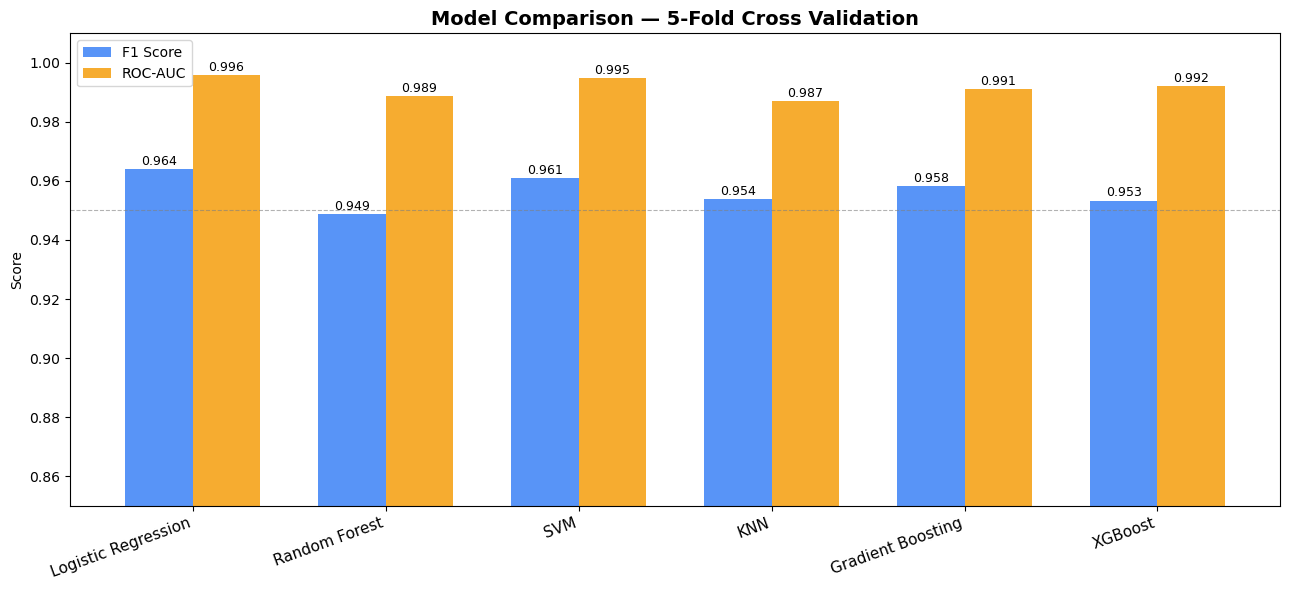

In [15]:
names  = list(results.keys())
f1s    = [results[n]['F1']      for n in names]
aucs   = [results[n]['ROC_AUC'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, f1s,  width, label='F1 Score',  color='#3b82f6', alpha=0.85)
bars2 = ax.bar(x + width/2, aucs, width, label='ROC-AUC',   color='#f59e0b', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=11)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 5-Fold Cross Validation', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.95, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

for bar in bars1: ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                               xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2: ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                               xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Train Best Model

In [16]:
best_model = models[best_name]
best_model.fit(X_train_sc, y_train)

y_pred  = best_model.predict(X_test_sc)
y_proba = best_model.predict_proba(X_test_sc)[:, 1]

print(f"✅ {best_name} trained on full training set")
print(f"\nTrain Accuracy : {best_model.score(X_train_sc, y_train):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred):.4f}")

✅ Logistic Regression trained on full training set

Train Accuracy : 0.9868
Test  Accuracy : 0.9649


# Full Evaluation

In [17]:
print("=" * 45)
print("       FINAL MODEL PERFORMANCE REPORT")
print("=" * 45)
print(f"  Model     : {best_name}")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print("=" * 45)
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

       FINAL MODEL PERFORMANCE REPORT
  Model     : Logistic Regression
  Accuracy  : 0.9649
  Precision : 0.9750
  Recall    : 0.9286
  F1 Score  : 0.9512
  ROC-AUC   : 0.9960

── Classification Report ──
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Confusion Matrix

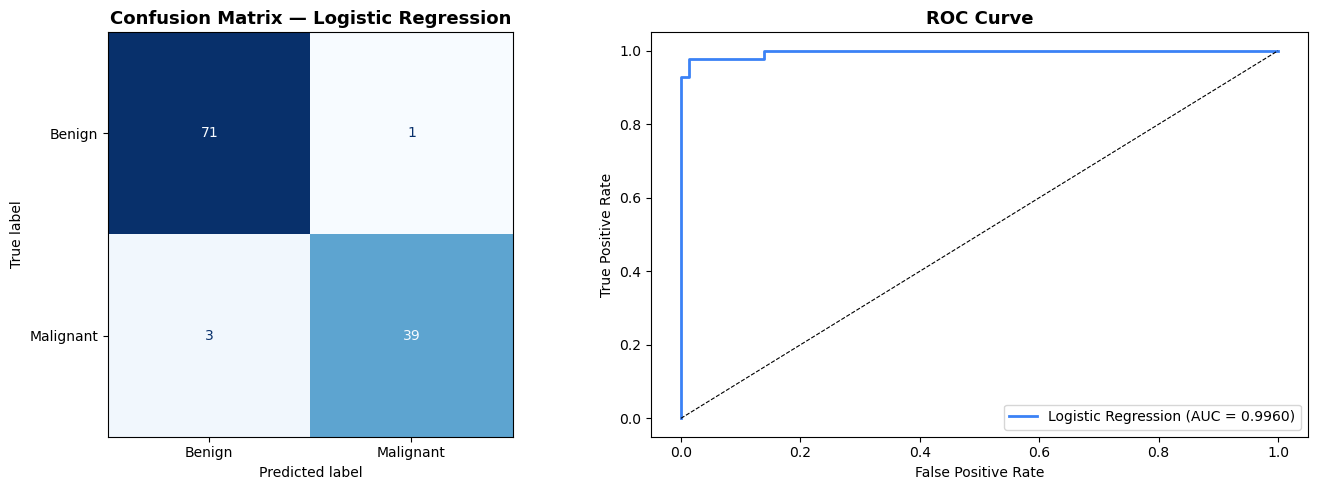

In [31]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

# ROC Curve (manual — works on all sklearn versions)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#3b82f6', linewidth=2, label=f'{best_name} (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Feature Importance (if tree-based)

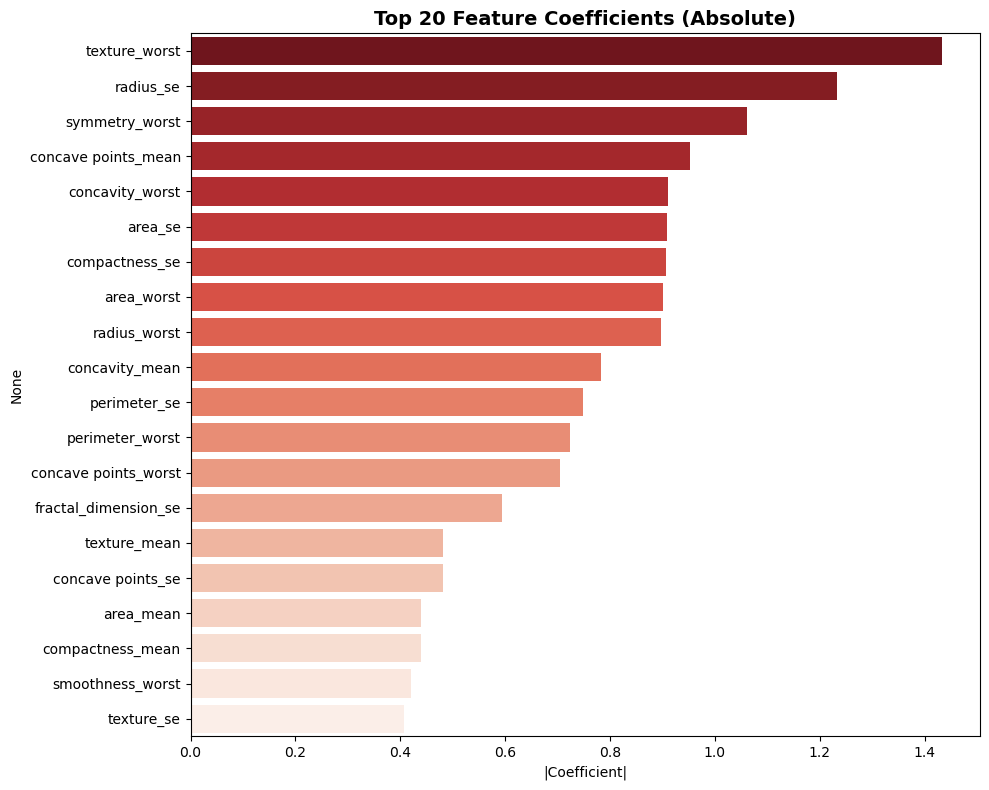

In [32]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top20 = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=top20.values, y=top20.index, palette='Blues_r')
    plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
    top20 = coef.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=top20.values, y=top20.index, palette='Reds_r')
    plt.title('Top 20 Feature Coefficients (Absolute)', fontsize=14, fontweight='bold')
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

# Save Model & Preprocessor

In [33]:
Path('../backend/models').mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, '../backend/models/breast_cancer_model.pkl')
joblib.dump(scaler,     '../backend/models/breast_cancer_preprocessor.pkl')

print("✅ Model saved      → backend/models/breast_cancer_model.pkl")
print("✅ Scaler saved     → backend/models/breast_cancer_preprocessor.pkl")
print(f"\nModel type : {type(best_model).__name__}")
print(f"F1 Score   : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC    : {roc_auc_score(y_test, y_proba):.4f}")

✅ Model saved      → backend/models/breast_cancer_model.pkl
✅ Scaler saved     → backend/models/breast_cancer_preprocessor.pkl

Model type : LogisticRegression
F1 Score   : 0.9512
ROC-AUC    : 0.9960
